55398 23742 (55398, 10) (23742, 10)
55398 23742
            MaxTemp       MinTemp       Temp9am       Temp3pm   Pressure3pm  \
count  55398.000000  55398.000000  55398.000000  55398.000000  55398.000000   
mean      23.632528     12.626672     17.427364     22.106719   1015.091287   
std        6.964157      6.223687      6.340894      6.814940      6.976438   
min        2.600000     -7.000000     -3.100000      2.300000    978.200000   
25%       18.200000      8.100000     12.700000     16.900000   1010.400000   
50%       23.100000     12.400000     17.000000     21.600000   1015.100000   
75%       28.600000     17.200000     22.000000     26.800000   1019.800000   
max       48.100000     33.900000     40.200000     46.700000   1039.600000   

        Pressure9am  WindGustSpeed  WindSpeed3pm  WindSpeed9am     RainToday  
count  55398.000000   55398.000000  55398.000000  55398.000000  55398.000000  
mean    1017.471504      40.747680     19.492274     15.175421      0.356890  
std

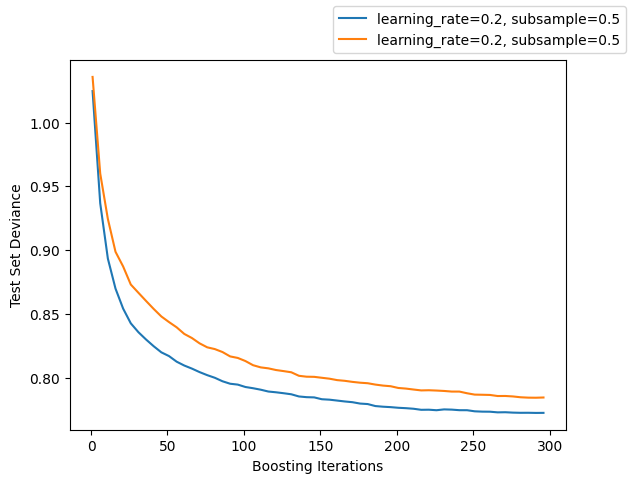

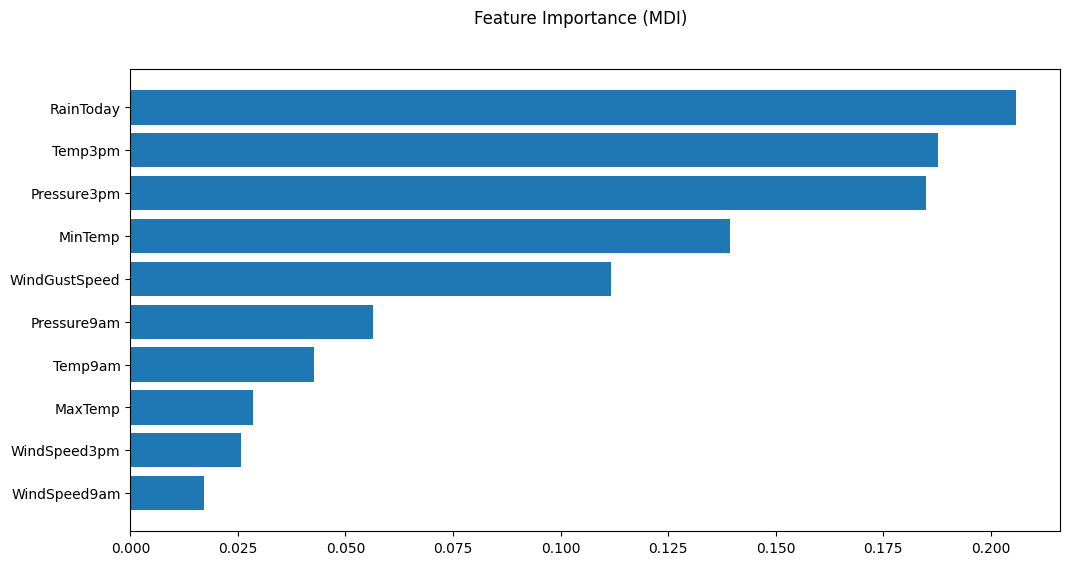

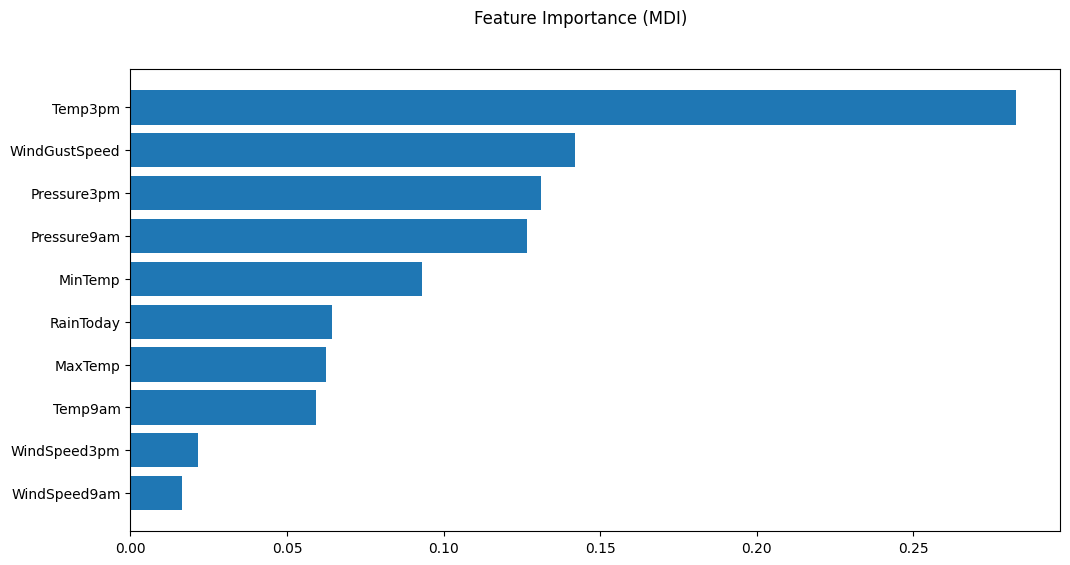

In [ ]:
import dataclasses
from typing import Dict, List

from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from src.utils import get_raw_results, res_raw
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import numpy as np

from sklearn import ensemble
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split


@dataclasses.dataclass
class RegressionConfig:
    n_runs: int = 10
    random_state: int | None = None
    learning_rate: float = 0.2
    subsample: float = 0.5
    n_estimators: int = 100
    test_size: float = 0.2
    max_depth: int | None = None
    cols: List[str] = dataclasses.field(
        default_factory=lambda: [
            # "Humidity3pm",
            # "Humidity9am",
            "MaxTemp",
            "MinTemp",
            "Temp9am",
            "Temp3pm",
            "Pressure3pm",
            "Pressure9am",
            "WindGustSpeed",
            "WindSpeed3pm",
            "WindSpeed9am",
            "RainToday",
            "RainTomorrow",
            # "Pressure",
            # "Humidity",
            # "Temp",
            # "WindSpeed",
        ]
    )
    thresholds: List[float] = dataclasses.field(
        default_factory=lambda: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    )


config = RegressionConfig()

df_raw = get_raw_results()

cleaned_results = df_raw[
    (df_raw["dataset"] == "weather")
    & (df_raw["metric"] == "completeness_nullAndDMVRatio")
    & (df_raw["type"] == "cleaned")
]
polluted_results = df_raw[
    (df_raw["dataset"] == "weather")
    & (df_raw["metric"] == "consistency_ruleBasedPipino")
    & (df_raw["dimension"] == "consistency_tuple")
    & (df_raw["type"] == "polluted")
    & (df_raw["pollution_mechanism"] == "ECAR")
    & (df_raw["pollution_rate"] == 0.35)
]

cleaned_data = pd.DataFrame(
    {res["column"]: res["result"].data for _, res in cleaned_results.iterrows()}
)

assert len(polluted_results) == 1, polluted_results

polluted_raw = res_raw(polluted_results)
polluted_data = pd.DataFrame(
    polluted_results.iloc[0]["result"].data,
    columns="row ID,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday,RainTomorrow".split(
        ","
    ),
)

polluted_dq = pd.Series(
    polluted_results.iloc[0]["result"].dq_result,
)
polluted_certainty = pd.Series(
    polluted_results.iloc[0]["result"].certainty,
)


# Transformation
def transform(data):
    data["RainToday"] = data["RainToday"].map({"Yes": 1, "No": 0})
    data["RainTomorrow"] = data["RainTomorrow"].map({"Yes": 1, "No": 0})
    # ["MaxTemp","MinTemp","Pressure3pm","Pressure9am","RainTomorrow","WindGustSpeed"]
    data["Pressure"] = (data["Pressure3pm"] + data["Pressure9am"]) / 2
    data["Humidity"] = (data["Humidity3pm"] + data["Humidity9am"]) / 2
    data["Temp"] = (data["Temp3pm"] + data["Temp9am"]) / 2
    data["WindSpeed"] = (data["WindSpeed3pm"] + data["WindSpeed9am"]) / 2
    return data[config.cols]


# https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_regression.html
def plot_feature_importance(clf: ensemble.GradientBoostingClassifier, feature_names):
    feature_importance = clf.feature_importances_
    sorted_idx = np.argsort(feature_importance)
    pos = np.arange(sorted_idx.shape[0]) + 0.5
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(pos, feature_importance[sorted_idx], align="center")
    ax.set_yticks(pos, feature_names[sorted_idx])
    fig.suptitle("Feature Importance (MDI)")
    return fig


cleaned_data = transform(cleaned_data)
polluted_data = transform(polluted_data)

all_idx = cleaned_data.index
results = {}


# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause
# https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_regularization.html#sphx-glr-auto-examples-ensemble-plot-gradient-boosting-regularization-py

X_c, y_c = cleaned_data.drop("RainTomorrow", axis=1), cleaned_data["RainTomorrow"]
X_p, y_p = polluted_data.drop("RainTomorrow", axis=1), polluted_data["RainTomorrow"]

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.3, random_state=0
)
X_p_train, X_p_test, y_p_train, y_p_test = train_test_split(
    X_p, y_p, test_size=0.3, random_state=0
)

original_params: Dict[str, float | None] = {
    "n_estimators": 300,
    "max_leaf_nodes": 4,
    "max_depth": None,
    "random_state": 2,
    "min_samples_split": 5,
}

loss_fig, loss_fig_ax = plt.subplots()

for label, color, setting in [
    # ("No shrinkage", "orange", {"learning_rate": 1.0, "subsample": 1.0}),
    # ("learning_rate=0.2", "turquoise", {"learning_rate": 0.2, "subsample": 1.0}),
    # ("subsample=0.5", "blue", {"learning_rate": 1.0, "subsample": 0.5}),
    (
        "learning_rate=0.2, subsample=0.5",
        "gray",
        {"learning_rate": 0.2, "subsample": 0.5},
    ),
    # (
    #     "learning_rate=0.2, max_features=2",
    #     "magenta",
    #     {"learning_rate": 0.2, "max_features": 2},
    # ),
]:
    for X_train, y_train, X_test, y_test in [
        (X_c_train, y_c_train, X_c_test, y_c_test),
        (X_p_train, y_p_train, X_c_test, y_c_test),
    ]:
        scaler = StandardScaler()
        scaler.fit(X_train)

        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        params = dict(original_params)
        params.update(setting)

        print(
            len(X_train_scaled),
            len(X_test_scaled),
            X_train_scaled.shape,
            X_test_scaled.shape,
        )
        print(len(y_train), len(y_test))

        print(X_train.describe())
        clf = ensemble.GradientBoostingClassifier(**params)
        clf.fit(X_train_scaled, y_train)

        # compute test set deviance
        test_deviance = np.zeros((params["n_estimators"],), dtype=np.float64)

        for i, y_proba in enumerate(clf.staged_predict_proba(X_test_scaled)):
            test_deviance[i] = 2 * log_loss(y_test, y_proba[:, 1])

        loss_fig_ax.plot(
            (np.arange(test_deviance.shape[0]) + 1)[::5],
            test_deviance[::5],
            "-",
            label=label,
        )
        plot_feature_importance(clf, X_c.columns)

    loss_fig.legend(loc="upper right")
    loss_fig_ax.set_xlabel("Boosting Iterations")
    loss_fig_ax.set_ylabel("Test Set Deviance")
None

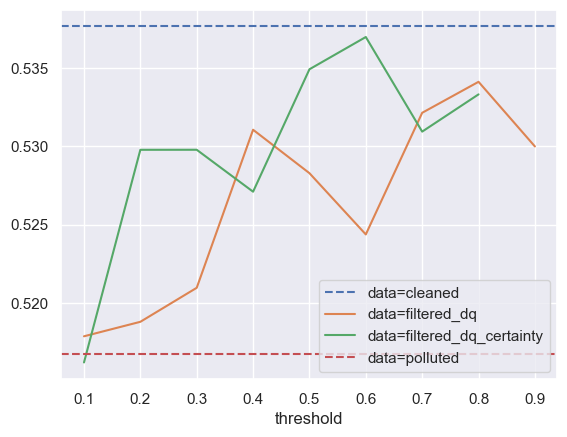

In [38]:
from pathlib import Path
from click import group
import seaborn as sns

sns.set_theme()

results_path = Path("regression-results")
results_folder = max(results_path.glob("*"))
df = pd.read_csv(results_folder / "results.csv")


fig, ax = plt.subplots()
for i, (data, group) in enumerate(df.groupby("data")):
    mean_scores = group.groupby("threshold", dropna=False)["score"].mean()
    if all(mean_scores.index.isna()):
        ax.axhline(
            mean_scores.iloc[0], color=f"C{i}", linestyle="--", label=f"data={data}"
        )
    else:
        mean_scores.plot(ax=ax, color=f"C{i}", label=f"data={data}")

ax.legend()

None

In [14]:
from sklearn.metrics import accuracy_score, classification_report

print(accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred))

0.8513393985342431
              precision    recall  f1-score   support

         0.0       0.87      0.95      0.91     12340
         1.0       0.74      0.50      0.60      3488

    accuracy                           0.85     15828
   macro avg       0.80      0.73      0.75     15828
weighted avg       0.84      0.85      0.84     15828



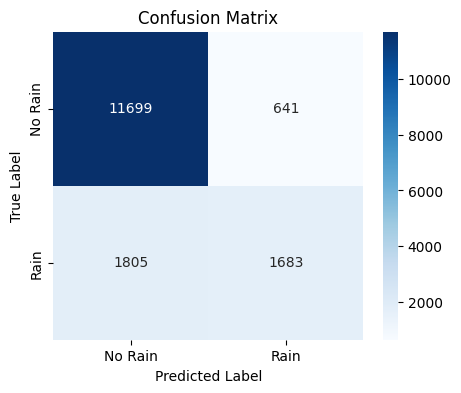

In [4]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Text(0.5, 0, 'False Positive Rate')

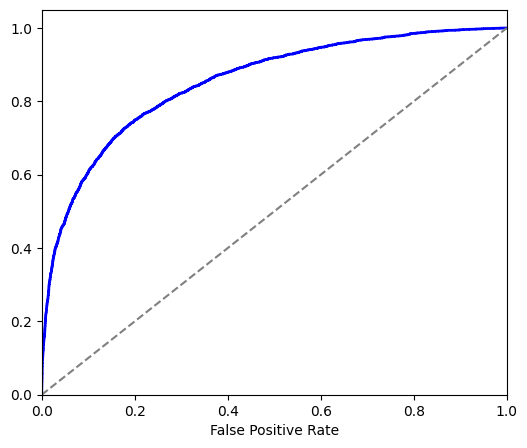

In [5]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")